<a href="https://colab.research.google.com/github/pzedros/metodos_numericos/blob/main/trabalho_4_de_metodos1_questao3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Questão 3

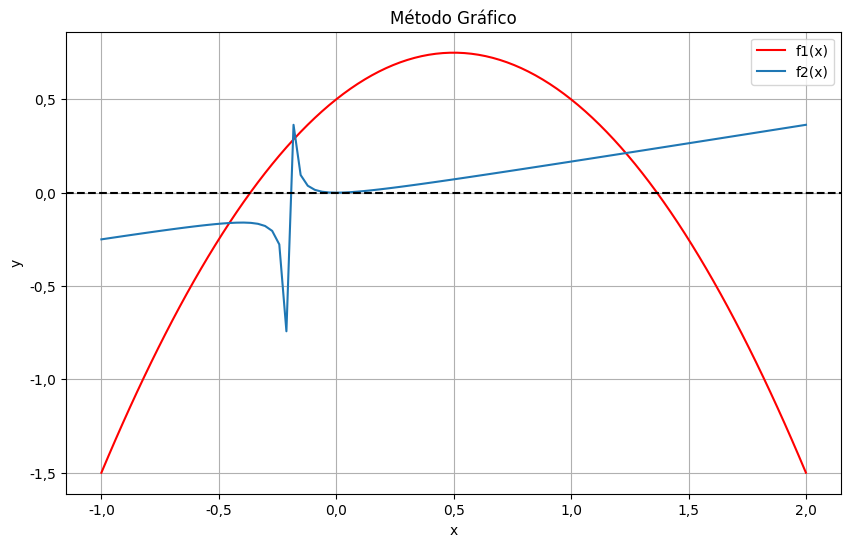

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def fy1(x):
    return -x**2 + x + 1/2

def fy2(x):
    return x**2 / (1 + 5*x)

x = np.linspace(-1, 2, 100)

plt.figure(figsize=(10, 6))
plt.plot(x, fy1(x), color='red', label='f1(x)')
plt.plot(x, fy2(x), label='f2(x)')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Método Gráfico')
plt.legend()
plt.grid()

# Configura os eixos para usar vírgula como separador decimal
formatter = ticker.FuncFormatter(lambda val, pos: f"{val:.1f}".replace('.', ','))
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.show()


   iterações         x         y   Epest % x  Epest % y
0          1  0.183333  0.883333  263.636364  88.679245
1          2 -0.046856  0.503936  491.271703  75.286880
2          3 -0.146282  0.342206   67.968798  47.261132
3          4 -0.175149  0.295007   16.481571  15.999031
4          5 -0.178097  0.290193    1.655241   1.658862
5          6 -0.178128  0.290142    0.017600   0.017650
6          7 -0.178128  0.290142    0.000002   0.000002
Solução encontrada:
x = -0.178128
y = 0.290142
Número de iterações: 7


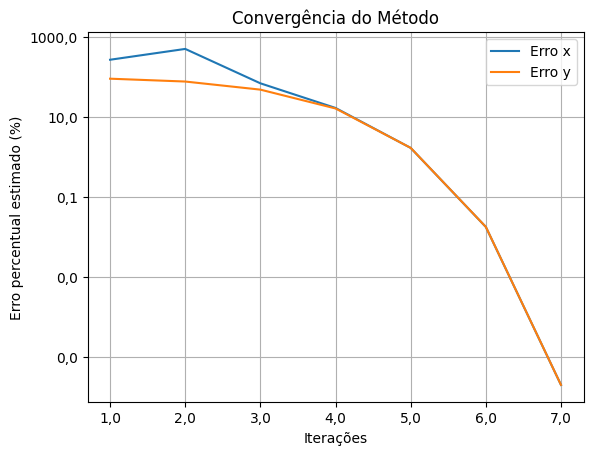

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

def f1(x, y):
  return y + x**2 - x - 1/2

def f2(x, y):
  return y + 5*x*y - x**2

def df1x(x, y):
  return 2*x - 1

def df1y(x, y):
  return 1

def df2x(x, y):
  return 5*y - 2*x

def df2y(x, y):
  return 1 + 5*x


v_old = np.array([-0.3, 0.1])  #[xold, yold]
v_new = v_old

Epest = np.array([100.0, 100.0])
n = 6
Eppara = 0.5*10**(2-n)
iteracao = 0

i = []
EPEST_x = []
EPEST_y = []
X = []
Y = []

while max(Epest) >= Eppara:
  x_new = v_old[0] - ((f1(v_old[0],v_old[1])*df2y(v_old[0], v_old[1]) - f2(v_old[0], v_old[1])*df1y(v_old[0], v_old[1]))/ (df1x(v_old[0], v_old[1])*df2y(v_old[0], v_old[1]) - df1y(v_old[0], v_old[1])*df2x(v_old[0], v_old[1])))
  y_new = v_old[1] - ((f2(v_old[0],v_old[1])*df1x(v_old[0], v_old[1]) - f1(v_old[0], v_old[1])*df2x(v_old[0], v_old[1]))/ (df1x(v_old[0], v_old[1])*df2y(v_old[0], v_old[1]) - df1y(v_old[0], v_old[1])*df2x(v_old[0], v_old[1])))

  v_new = np.array([x_new, y_new])
  Epest = abs((v_new - v_old)/v_new)*100
  v_old = v_new
  iteracao += 1

  i.append(iteracao)
  EPEST_x.append(Epest[0])
  EPEST_y.append(Epest[1])
  X.append(x_new)
  Y.append(y_new)

table = pd.DataFrame()
table['iterações'] = i
table['x'] = X
table['y'] = Y
table['Epest % x'] = EPEST_x
table['Epest % y'] = EPEST_y
print(table)

print("Solução encontrada:")
print(f"x = {v_new[0]:.6f}")
print(f"y = {v_new[1]:.6f}")
print(f"Número de iterações: {iteracao}")

plt.plot(i, EPEST_x, label='Erro x')
plt.plot(i, EPEST_y, label='Erro y')
plt.xlabel('Iterações')
plt.ylabel('Erro percentual estimado (%)')
plt.yscale('log')
plt.legend()
plt.title('Convergência do Método')
plt.grid(True)

# Configura os eixos para usar vírgula como separador decimal
formatter = ticker.FuncFormatter(lambda val, pos: f"{val:.1f}".replace('.', ','))
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.show()
